# Robot Current Monitoring: Regression and Residual Analysis

This notebook examines current measurements from eight robot axes. For each axis, elapsed time is used as the input to a linear-regression baseline; residuals describe how far observed currents differ from that baseline. The workflow also explores upper-tail residual cutoffs and evaluates a separate synthetic stream for sustained alerts and errors.

**Provenance:** This work adapts a peer-provided starter project with permission. The source measurement CSV has not been altered; the analysis narrative and plots are being revised.

The remaining sections document data checks, model fitting, residual-based thresholds, a separate synthetic test stream, and the alert-monitoring dashboard.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Environment is ready.")
print("Project root:", project_root)

Environment is ready.
Project root: d:\Foundation of Machine Learning\week 3\PredictiveMaintenance


## 1. Load and Inspect the Training Data

The training dataset contains historical robot axis current measurements. Before building any machine learning model, the dataset is inspected to understand its structure, columns, size, and data quality.

In [2]:
csv_path = (
    project_root
    / "data"
    / "RMBR4-2_export_test.csv"
)

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully.
Number of rows: 39672
Number of columns: 16


## 2. Understand the Dataset Columns

The dataset is inspected to identify the timestamp column and the eight robot axes required for the regression models.

In [3]:
print("Column names:")
print(df.columns.tolist())

df.head()

Column names:
['Trait', 'Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Axis #9', 'Axis #10', 'Axis #11', 'Axis #12', 'Axis #13', 'Axis #14', 'Time']


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


## 3. Check Data Types and Missing Values

The dataset is checked for missing values and incorrect data types before analysis. This helps identify which columns are usable for the predictive maintenance models.

In [4]:
print("Data types:")
print(df.dtypes)

print("\nMissing values in each column:")
print(df.isnull().sum())

Data types:
Trait           str
Axis #1     float64
Axis #2     float64
Axis #3     float64
Axis #4     float64
Axis #5     float64
Axis #6     float64
Axis #7     float64
Axis #8     float64
Axis #9     float64
Axis #10    float64
Axis #11    float64
Axis #12    float64
Axis #13    float64
Axis #14    float64
Time            str
dtype: object

Missing values in each column:
Trait           0
Axis #1         0
Axis #2         0
Axis #3         0
Axis #4         0
Axis #5         0
Axis #6         0
Axis #7         0
Axis #8         0
Axis #9     39672
Axis #10    39672
Axis #11    39672
Axis #12    39672
Axis #13    39672
Axis #14    39672
Time            0
dtype: int64


### Data Quality Observation

Axis #1 through Axis #8 contain valid current measurements and will be used for this project.

Axis #9 through Axis #14 contain only missing values and are therefore excluded from the analysis. The assignment requires regression models only for Axis #1 through Axis #8.

In [5]:
axis_columns = [
    "Axis #1",
    "Axis #2",
    "Axis #3",
    "Axis #4",
    "Axis #5",
    "Axis #6",
    "Axis #7",
    "Axis #8"
]

print("Axes selected for analysis:")
print(axis_columns)

Axes selected for analysis:
['Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8']


## 4. Prepare the Time Column

The original `Time` column is converted from text into a datetime format.  
An elapsed-time variable is then created so that Linear Regression can use time as a numeric input.

The original timestamps are preserved because they will also be needed later to calculate how long Alert and Error conditions persist.

In [6]:
working_df = df[["Time", *axis_columns]].copy()

working_df["Time"] = pd.to_datetime(
    working_df["Time"],
    utc=True,
    errors="coerce"
)

working_df = working_df.sort_values("Time").reset_index(drop=True)

print("Invalid timestamps:", working_df["Time"].isnull().sum())

working_df.head()

Invalid timestamps: 0


,Time,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8
0,2022-10-17 12:18:23.660000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
start_time = working_df["Time"].iloc[0]

working_df["Elapsed_Seconds"] = (
    working_df["Time"] - start_time
).dt.total_seconds()

working_df[
    ["Time", "Elapsed_Seconds", "Axis #1"]
].head(10)

,Time,Elapsed_Seconds,Axis #1
0,2022-10-17 12:18:23.660000+00:00,0.000,0.0
1,2022-10-17 12:18:25.472000+00:00,1.812,0.0
2,2022-10-17 12:18:27.348000+00:00,3.688,0.0
3,2022-10-17 12:18:29.222000+00:00,5.562,0.0
4,2022-10-17 12:18:31.117000+00:00,7.457,0.0
5,2022-10-17 12:18:32.964000+00:00,9.304,0.0
6,2022-10-17 12:18:34.894000+00:00,11.234,0.0
7,2022-10-17 12:18:36.782000+00:00,13.122,0.0
8,2022-10-17 12:18:38.708000+00:00,15.048,0.0
9,2022-10-17 12:18:40.529000+00:00,16.869,0.0


In [8]:
working_df["Time_Difference_Seconds"] = (
    working_df["Time"].diff().dt.total_seconds()
)

print(
    "Typical time between readings:",
    working_df["Time_Difference_Seconds"].median(),
    "seconds"
)

print(
    "Smallest time difference:",
    working_df["Time_Difference_Seconds"].min(),
    "seconds"
)

print(
    "Largest time difference:",
    working_df["Time_Difference_Seconds"].max(),
    "seconds"
)

Typical time between readings: 1.891 seconds
Smallest time difference: 1.714 seconds
Largest time difference: 402.538 seconds


## 5. Explore Current Statistics

Basic statistics are calculated for Axis #1 through Axis #8 to understand their normal ranges, averages, variation, and maximum values before fitting regression models.

In [9]:
axis_stats = working_df[axis_columns].describe().T

axis_stats

,count,mean,std,min,25%,50%,75%,max
Axis #1,39672.0,0.725743,2.162120,0.0,0.0,0.0,0.31271,23.60930
Axis #2,39672.0,3.613374,6.879962,0.0,0.0,0.0,4.21719,51.71323
Axis #3,39672.0,2.710336,5.111901,0.0,0.0,0.0,4.58619,41.85556
Axis #4,39672.0,0.620222,1.574897,0.0,0.0,0.0,0.51619,15.66630
Axis #5,39672.0,0.954521,2.100186,0.0,0.0,0.0,0.80009,20.75076
Axis #6,39672.0,0.599427,1.815498,0.0,0.0,0.0,0.36133,20.93142
Axis #7,39672.0,0.870145,2.166811,0.0,0.0,0.0,0.31003,8.10848
Axis #8,39672.0,0.102214,0.423075,0.0,0.0,0.0,0.07848,5.90564


### Zero-Current Readings

A large percentage of the robot current measurements are zero. These values are examined rather than removed automatically because they may represent legitimate periods when the robot is idle.

In [10]:
zero_percentages = (
    (working_df[axis_columns] == 0).mean() * 100
).round(2)

print("Percentage of zero readings:")
print(zero_percentages)

Percentage of zero readings:
Axis #1    65.32
Axis #2    65.09
Axis #3    65.14
Axis #4    65.55
Axis #5    65.19
Axis #6    65.72
Axis #7    65.56
Axis #8    65.43
dtype: float64


### Machine State Indicator

A simple machine-state indicator is created to distinguish between idle and running observations.

A row is classified as `IDLE` when all eight axis currents are zero. If at least one axis has a non-zero current measurement, the row is classified as `RUNNING`.

In [11]:
working_df["Machine_State"] = np.where(
    working_df[axis_columns].ne(0).any(axis=1),
    "RUNNING",
    "IDLE"
)

working_df["Machine_State"].value_counts()

Machine_State
IDLE       25487
RUNNING    14185
Name: count, dtype: int64

### Running vs Idle Distribution

The percentage of historical observations classified as `RUNNING` and `IDLE` is calculated to better understand the operating behaviour represented in the training dataset.

In [12]:
state_percentages = (
    working_df["Machine_State"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Machine state percentages:")
print(state_percentages)

Machine state percentages:
Machine_State
IDLE       64.24
RUNNING    35.76
Name: proportion, dtype: float64


### Observation

A large portion of the dataset contains zero-current readings. These values are not removed automatically because they may represent legitimate idle periods rather than missing or incorrect data.

A `Machine_State` indicator is therefore created to distinguish rows where all eight axes are zero (`IDLE`) from rows where at least one axis is active (`RUNNING`).

## 6. Connect to Neon PostgreSQL

The project uses an Object-Oriented `DatabaseManager` class to securely connect to the Neon PostgreSQL database. Database credentials are stored in a local `.env` file and are not committed to GitHub.

In [13]:
from src.database_manager import DatabaseManager

In [14]:
db = DatabaseManager()

database_version = db.test_connection()

print("Connected successfully to Neon PostgreSQL.")
print(database_version)

Connected successfully to Neon PostgreSQL.
PostgreSQL 18.6 (4e955f5) on aarch64-unknown-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0, 64-bit


### Create the Training Table

A PostgreSQL table is created in Neon to store the historical robot current measurements. The table contains the original timestamp, trait, and current measurements for Axis #1 through Axis #8.

In [15]:
db.create_training_table()

print("Training table created successfully.")

Training table created successfully.


### Upload Historical Training Data to Neon

The historical CSV data is uploaded to the Neon PostgreSQL `training_data` table. Only the timestamp, trait, and Axis #1 through Axis #8 are stored because the remaining axis columns contain no usable observations.To prevent duplicate historical records, the upload method checks whether the training table already contains data before inserting the CSV again.

In [16]:
db.upload_training_data(df)

Training table already contains 39672 rows. Upload skipped.


In [17]:
row_count = db.count_training_rows()

print("Rows currently stored in Neon:", row_count)

Rows currently stored in Neon: 39672


### Retrieve Training Data from Neon

The historical measurements are queried back from the Neon PostgreSQL database. From this point forward, the regression models will use this database-derived DataFrame rather than reading the training CSV directly.

In [18]:
training_df = db.fetch_training_data()

print("Training data retrieved from Neon.")
print("Number of rows:", training_df.shape[0])
print("Number of columns:", training_df.shape[1])

training_df.head()

Training data retrieved from Neon.
Number of rows: 39672
Number of columns: 11


,id,sampled_at,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,1,2022-10-17 12:18:23.660000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2022-10-17 12:18:25.472000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2022-10-17 12:18:27.348000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2022-10-17 12:18:29.222000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2022-10-17 12:18:31.117000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Prepare Database Training Data for Regression

The historical training data is retrieved from Neon PostgreSQL.  
The timestamp is converted into elapsed seconds so that time can be used as the input variable for the Linear Regression models.

In [19]:
training_df["sampled_at"] = pd.to_datetime(
    training_df["sampled_at"],
    utc=True
)

training_df = training_df.sort_values(
    "sampled_at"
).reset_index(drop=True)

training_start_time = training_df["sampled_at"].iloc[0]

training_df["elapsed_seconds"] = (
    training_df["sampled_at"] - training_start_time
).dt.total_seconds()

training_df[
    ["sampled_at", "elapsed_seconds", "axis_1"]
].head(10)

,sampled_at,elapsed_seconds,axis_1
0,2022-10-17 12:18:23.660000+00:00,0.000,0.0
1,2022-10-17 12:18:25.472000+00:00,1.812,0.0
2,2022-10-17 12:18:27.348000+00:00,3.688,0.0
3,2022-10-17 12:18:29.222000+00:00,5.562,0.0
4,2022-10-17 12:18:31.117000+00:00,7.457,0.0
5,2022-10-17 12:18:32.964000+00:00,9.304,0.0
6,2022-10-17 12:18:34.894000+00:00,11.234,0.0
7,2022-10-17 12:18:36.782000+00:00,13.122,0.0
8,2022-10-17 12:18:38.708000+00:00,15.048,0.0
9,2022-10-17 12:18:40.529000+00:00,16.869,0.0


In [20]:
db_axis_columns = [
    "axis_1",
    "axis_2",
    "axis_3",
    "axis_4",
    "axis_5",
    "axis_6",
    "axis_7",
    "axis_8",
]

print(db_axis_columns)

['axis_1', 'axis_2', 'axis_3', 'axis_4', 'axis_5', 'axis_6', 'axis_7', 'axis_8']


## 8. Train Linear Regression Models for Axis 1–8 Using OOP

A reusable `RegressionManager` class is used to train eight independent univariate Linear Regression models.

For every model:

- Input `X` = elapsed time in seconds
- Target `y` = current measurement for one robot axis

The `RegressionManager` stores the trained model, slope, and intercept for each axis and is also used to calculate predictions and residuals.

This avoids duplicating regression logic inside the notebook.

In [21]:
from src.regression_manager import RegressionManager

regression_manager = RegressionManager()

print("RegressionManager created successfully.")

RegressionManager created successfully.


In [22]:
model_information = regression_manager.train_models(
    training_df
)

print("All 8 regression models trained successfully.")

All 8 regression models trained successfully.


### Model Slopes and Intercepts

In [23]:
model_summary = regression_manager.get_model_summary()

model_summary

,slope,intercept
axis_1,-1.176729e-07,0.730542
axis_2,2.194203e-06,3.523886
axis_3,-5.777186e-07,2.733898
axis_4,3.890034e-07,0.604357
axis_5,8.381178e-08,0.951103
axis_6,4.744455e-07,0.580077
axis_7,5.537186e-07,0.847563
axis_8,8.499989e-08,0.098748


### Generate Predictions and Residuals for All Eight Axes

In [24]:
regression_results_df = (
    regression_manager.add_predictions_and_residuals(
        training_df
    )
)

print("Predictions and residuals calculated for all axes.")

regression_results_df.head()

Predictions and residuals calculated for all axes.


,id,sampled_at,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,...,axis_4_predicted,axis_4_residual,axis_5_predicted,axis_5_residual,axis_6_predicted,axis_6_residual,axis_7_predicted,axis_7_residual,axis_8_predicted,axis_8_residual
0,1,2022-10-17 12:18:23.660000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.604357,-0.604357,0.951103,-0.951103,0.580077,-0.580077,0.847563,-0.847563,0.098748,-0.098748
1,2,2022-10-17 12:18:25.472000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.604358,-0.604358,0.951103,-0.951103,0.580078,-0.580078,0.847564,-0.847564,0.098748,-0.098748
2,3,2022-10-17 12:18:27.348000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.604358,-0.604358,0.951103,-0.951103,0.580079,-0.580079,0.847565,-0.847565,0.098748,-0.098748
3,4,2022-10-17 12:18:29.222000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.604359,-0.604359,0.951103,-0.951103,0.580080,-0.580080,0.847566,-0.847566,0.098748,-0.098748
4,5,2022-10-17 12:18:31.117000+00:00,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.604360,-0.604360,0.951103,-0.951103,0.580081,-0.580081,0.847567,-0.847567,0.098748,-0.098748


## 9. Residual Analysis for Axis 1–8

Residuals are calculated as:

**Residual = Actual Current - Predicted Current**

Positive residuals represent current measurements above the regression prediction. Residual statistics and percentiles are analyzed to identify unusually high deviations that can later be used to justify Alert and Error thresholds.

In [25]:
residual_summary = regression_manager.get_residual_summary(
    regression_results_df
)

residual_summary

,axis,mean_residual,std_residual,max_residual,positive_95th_percentile,positive_99th_percentile
0,axis_1,-5.731339e-17,2.162118,22.881511,11.343826,20.026619
1,axis_2,2.980296e-16,6.879775,48.082660,24.567595,39.450935
2,axis_3,3.668057e-16,5.111883,39.160990,19.659364,27.697359
3,axis_4,6.304473e-17,1.574871,15.054179,7.206002,11.713580
4,axis_5,-8.023874e-17,2.100185,19.796448,8.516996,14.036251
5,axis_6,-1.203581e-16,1.815465,20.320990,9.469247,14.367856
6,axis_7,-1.719402e-16,2.166773,7.260771,7.232741,7.247293
7,axis_8,0.000000e+00,0.423071,5.802731,3.136179,4.077765


In [26]:
highest_variation_axis = residual_summary.loc[
    residual_summary["std_residual"].idxmax()
]

print("Axis with highest residual variation:")
print(highest_variation_axis["axis"])

print(
    "Residual standard deviation:",
    highest_variation_axis["std_residual"]
)

Axis with highest residual variation:
axis_2
Residual standard deviation: 6.879774509285571


## 10. Visualizing Model Fit and Residual Spread

The model-fit panels use hexbin shading so dense regions of the measured current series remain visible, with the fitted linear baseline drawn over them.

The residual panels show one histogram per axis. The vertical reference at zero marks an exact prediction; the 95th and 99th percentiles of positive residuals are shown as candidate upper-tail cutoffs. All plots use the existing measurements and calculated predictions without changing the CSV values.

In [27]:
from src.visualizer import AnalysisVisualizer

visualizer = AnalysisVisualizer()

print("AnalysisVisualizer created successfully.")

AnalysisVisualizer created successfully.


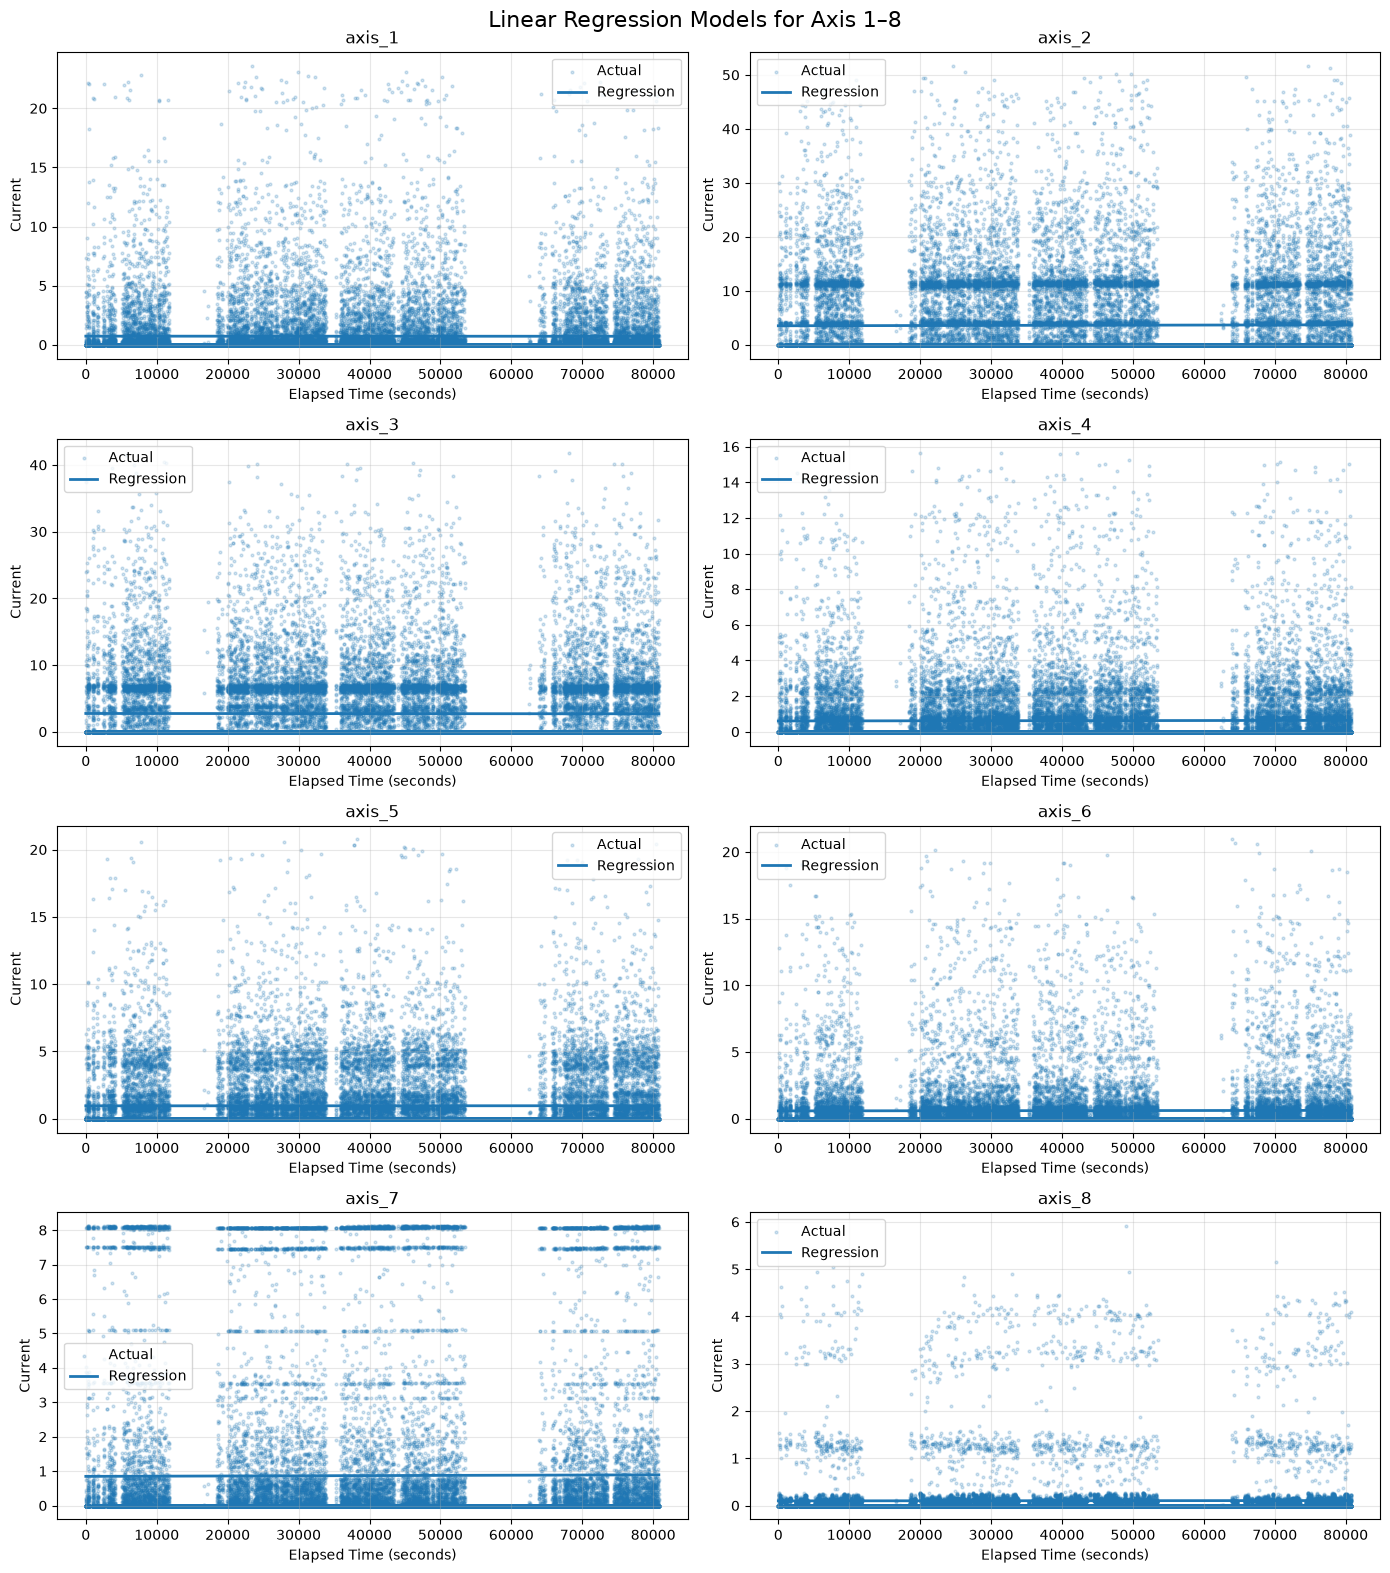

In [28]:
regression_image_path = project_root / "images" / "regression_models.png"

visualizer.plot_regressions(
    regression_results_df,
    save_path=regression_image_path
)

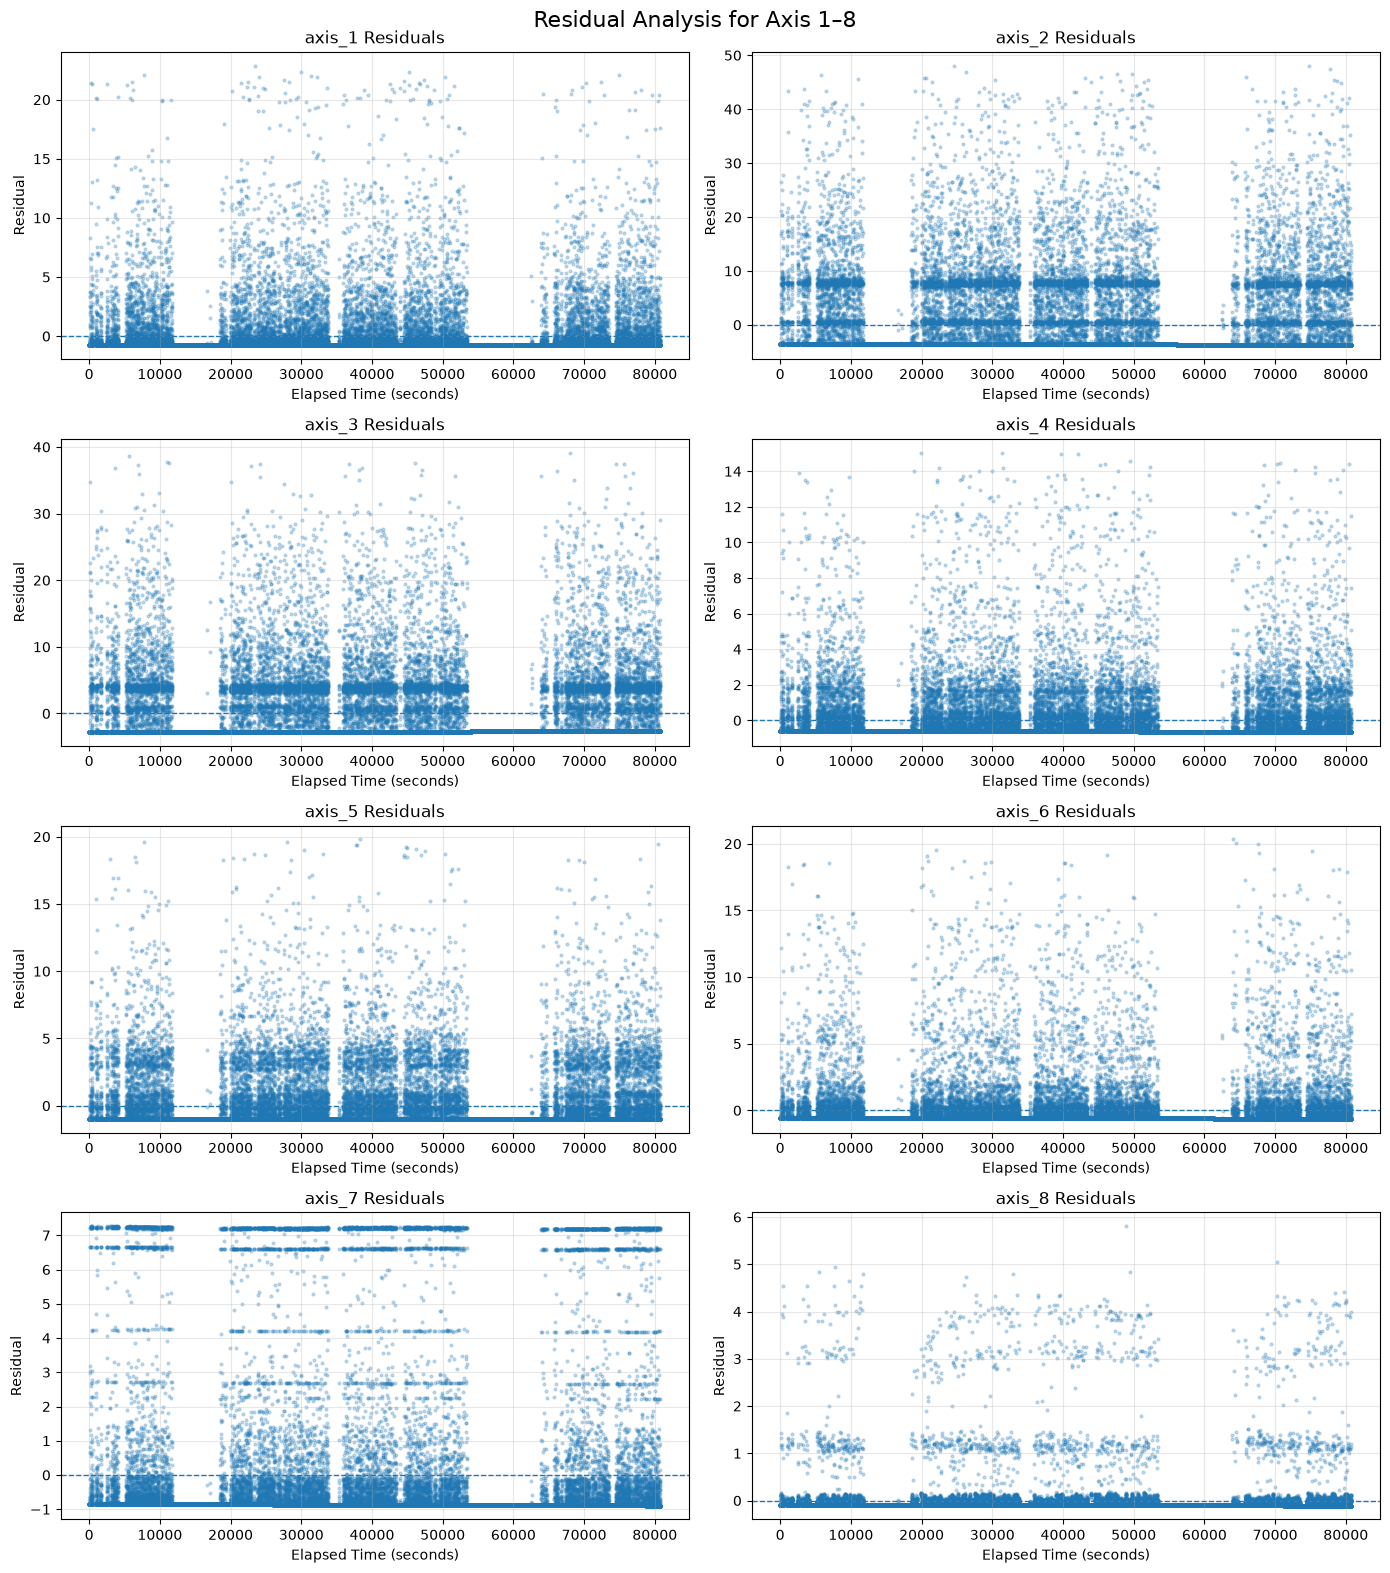

In [29]:
residual_image_path = (
    project_root
    / "images"
    / "residual_analysis.png"
)

visualizer.plot_residuals(
    regression_results_df,
    save_path=residual_image_path
)

## 11. Threshold Discovery

Alert and Error thresholds are derived from the historical residual distributions rather than selected arbitrarily.

For each axis:

- the 95th percentile of positive residuals is examined as the Alert threshold (`MinC`)
- the 99th percentile of positive residuals is examined as the Error threshold (`MaxC`)

Because the eight robot axes operate on different current scales, the threshold values are calculated separately for each axis.

In [30]:
threshold_candidates = residual_summary[
    [
        "axis",
        "positive_95th_percentile",
        "positive_99th_percentile"
    ]
].copy()

threshold_candidates = threshold_candidates.rename(
    columns={
        "positive_95th_percentile": "Alert_Candidate_95",
        "positive_99th_percentile": "Error_Candidate_99"
    }
)

threshold_candidates

,axis,Alert_Candidate_95,Error_Candidate_99
0,axis_1,11.343826,20.026619
1,axis_2,24.567595,39.450935
2,axis_3,19.659364,27.697359
3,axis_4,7.206002,11.713580
4,axis_5,8.516996,14.036251
5,axis_6,9.469247,14.367856
6,axis_7,7.232741,7.247293
7,axis_8,3.136179,4.077765


### Visualize the Candidate Thresholds

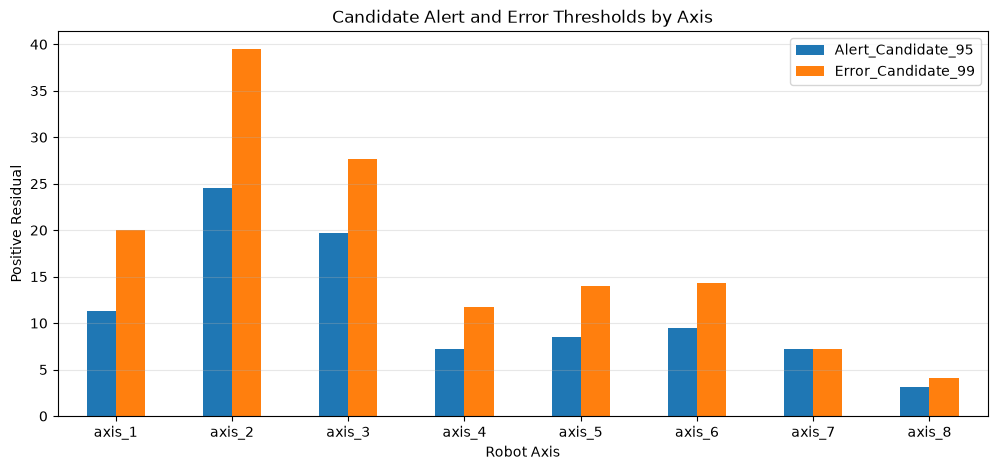

In [31]:
threshold_candidates.set_index("axis").plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Candidate Alert and Error Thresholds by Axis")
plt.xlabel("Robot Axis")
plt.ylabel("Positive Residual")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [32]:
sample_interval = training_df[
    "sampled_at"
].diff().dt.total_seconds().median()

print(
    "Typical time between readings:",
    round(sample_interval, 2),
    "seconds"
)

Typical time between readings: 1.89 seconds


### Final Threshold Interpretation

The residual analysis shows that the eight robot axes have different operating ranges and residual distributions. Therefore, applying one identical raw-current threshold to every axis would not fairly represent normal behaviour.

For each axis:

- `MinC` is defined as the 95th percentile of positive training residuals.
- `MaxC` is defined as the 99th percentile of positive training residuals.

The typical historical sampling interval is approximately **1.89 seconds**.

A shared persistence duration of:

**T = 10 seconds**

is selected so that an isolated high-current reading does not immediately create a maintenance event. With readings arriving approximately every two seconds, a sustained condition must remain abnormal across several consecutive observations before an Alert or Error is generated.

The selected thresholds and persistence rule are validated later using controlled synthetic anomalies.

In [33]:
thresholds = {}

for _, row in threshold_candidates.iterrows():
    thresholds[row["axis"]] = {
        "MinC": row["Alert_Candidate_95"],
        "MaxC": row["Error_Candidate_99"]
    }

thresholds

{'axis_1': {'MinC': 11.343826265567499, 'MaxC': 20.026619426558103},
 'axis_2': {'MinC': 24.567595268153628, 'MaxC': 39.45093525815368},
 'axis_3': {'MinC': 19.659363741319826, 'MaxC': 27.697358821767182},
 'axis_4': {'MinC': 7.2060023250426966, 'MaxC': 11.713580205131063},
 'axis_5': {'MinC': 8.516996158758166, 'MaxC': 14.036251492053632},
 'axis_6': {'MinC': 9.469247153402463, 'MaxC': 14.36785587524168},
 'axis_7': {'MinC': 7.232741190149831, 'MaxC': 7.247292667434605},
 'axis_8': {'MinC': 3.136178541982043, 'MaxC': 4.077765126616697}}

## 12. Generate Synthetic Testing Data

New testing data is generated using information learned from the historical training data retrieved from Neon PostgreSQL.

For each axis, the regression model provides the expected current and historical residual behaviour is sampled to create realistic variation around that prediction.

A fixed random seed is used so that the synthetic dataset can be reproduced. The validation scenario contains 150 rows at two-second intervals and is labeled `SYNTHETIC_TEST`; these are generated test records, not additional genuine measurements.

In [ ]:
from src.synthetic_data_generator import SyntheticDataGenerator

synthetic_generator = SyntheticDataGenerator(
    training_df=regression_results_df,
    regression_manager=regression_manager,
    thresholds=thresholds
)

synthetic_test_df = synthetic_generator.generate(
    number_of_rows=150,
    interval_seconds=2
)

synthetic_test_df["data_origin"] = "SYNTHETIC_TEST"
synthetic_test_df["scenario_id"] = "synthetic_150_record_validation"

synthetic_test_df.head()

In [ ]:
print("Synthetic test rows:", len(synthetic_test_df))

print(
    "Synthetic test duration:",
    (
        synthetic_test_df["sampled_at"].max()
        - synthetic_test_df["sampled_at"].min()
    )
)

### Compare Synthetic and Training Statistics

The mean and standard deviation of the synthetic measurements are compared with the historical Neon training data to confirm that the generated test data remains on a similar operating scale.

In [ ]:
training_statistics = regression_results_df[
    db_axis_columns
].agg(["mean", "std"]).T

synthetic_statistics = synthetic_test_df[
    db_axis_columns
].agg(["mean", "std"]).T

statistics_comparison = training_statistics.join(
    synthetic_statistics,
    lsuffix="_training",
    rsuffix="_synthetic"
)

statistics_comparison

### Statistical Comparison Observation

The synthetic means and standard deviations are not expected to exactly match the historical data because the synthetic records are newly generated observations.

However, the values remain on a similar operating scale to the training data, which supports their use as realistic testing measurements rather than arbitrary random values.

## 13. Normalize and Standardize Synthetic Testing Data

The preprocessing parameters are learned only from the historical training data retrieved from Neon PostgreSQL.

Two transformations are demonstrated:

- **Min-Max Normalization** scales values relative to the training minimum and maximum.
- **Z-score Standardization** measures values relative to the training mean and standard deviation.

The scalers are fitted only on training data and then applied to the synthetic testing data to avoid data leakage.

The original raw current values are preserved because regression residuals and Alert/Error thresholds are evaluated in the original current scale.

A normalized testing value may occasionally fall below 0 or above 1 when a new measurement lies outside the minimum or maximum observed in the training data. This does not mean the transformation is incorrect.

In [ ]:
from src.data_preprocessor import DataPreprocessor

preprocessor = DataPreprocessor()

preprocessor.fit_on_training_data(
    regression_results_df
)

processed_test_df = preprocessor.transform_test_data(
    synthetic_test_df
)

print("Synthetic test data processed successfully.")

processed_test_df.head()

In [ ]:
print("Training minimum values:")
print(
    pd.Series(
        preprocessor.minmax_scaler.data_min_,
        index=db_axis_columns
    )
)

print("\nTraining maximum values:")
print(
    pd.Series(
        preprocessor.minmax_scaler.data_max_,
        index=db_axis_columns
    )
)

print("\nTraining means used for standardization:")
print(
    pd.Series(
        preprocessor.standard_scaler.mean_,
        index=db_axis_columns
    )
)

## 14. Inject Controlled Test Anomalies

Controlled abnormal periods are inserted into this clearly labeled synthetic validation scenario to verify that the Alert/Error detection system works correctly. Historical measurement files remain unchanged; event counts shown by the dashboard are computed by running the detector over these simulated records.

The injected anomalies are defined relative to each axis's regression prediction rather than using arbitrary absolute current values.

An Alert-level anomaly is placed above `MinC` but below `MaxC`, while an Error-level anomaly is placed above `MaxC`.

In [ ]:
for start_row in [5, 40, 75, 110]:
    synthetic_test_df = synthetic_generator.inject_anomaly(
        dataframe=synthetic_test_df,
        axis="axis_2",
        start_row=start_row,
        number_of_rows=8,
        event_type="ALERT"
    )

print("Four separated Alert periods injected into Axis 2.")

In [ ]:
for start_row in [20, 55, 90, 125]:
    synthetic_test_df = synthetic_generator.inject_anomaly(
        dataframe=synthetic_test_df,
        axis="axis_6",
        start_row=start_row,
        number_of_rows=8,
        event_type="ERROR"
    )

print("Four separated Error periods injected into Axis 6.")

### Verify the Injected Alert

In [ ]:
axis2_model = regression_manager.models["axis_2"]

alert_rows = synthetic_test_df.iloc[40:48].copy()

alert_rows["predicted"] = axis2_model.predict(
    alert_rows[["elapsed_seconds"]]
)

alert_rows["residual"] = (
    alert_rows["axis_2"]
    - alert_rows["predicted"]
)

print("Axis 2 MinC:", thresholds["axis_2"]["MinC"])
print("Axis 2 MaxC:", thresholds["axis_2"]["MaxC"])

alert_rows[
    [
        "sampled_at",
        "axis_2",
        "predicted",
        "residual"
    ]
]

### Verify the Injected Error

In [ ]:
axis6_model = regression_manager.models["axis_6"]

error_rows = synthetic_test_df.iloc[125:133].copy()

error_rows["predicted"] = axis6_model.predict(
    error_rows[["elapsed_seconds"]]
)

error_rows["residual"] = (
    error_rows["axis_6"]
    - error_rows["predicted"]
)

print("Axis 6 MaxC:", thresholds["axis_6"]["MaxC"])

error_rows[
    [
        "sampled_at",
        "axis_6",
        "predicted",
        "residual"
    ]
]

In [ ]:
processed_test_df = preprocessor.transform_test_data(
    synthetic_test_df
)

print(
    "Synthetic test data reprocessed after anomaly injection."
)

### Save the Final Synthetic Test CSV

In [ ]:
synthetic_csv_path = (
    project_root
    / "data"
    / "synthetic_test_data.csv"
)

processed_test_df.to_csv(
    synthetic_csv_path,
    index=False
)

print(
    "Synthetic testing data saved to:",
    synthetic_csv_path
)

## 15. Prepare CSV-to-Database Streaming

The processed synthetic testing CSV will be replayed as a simulated live robot data stream.

The `StreamSimulator` reads the CSV one record at a time. During the final end-to-end test, records are delivered at approximately two-second intervals, inserted into the Neon PostgreSQL `streaming_data` table, and evaluated by the AlertDetector.

In [ ]:
db.create_streaming_table()

print(
    "Streaming table created successfully."
)

In [ ]:
from src.stream_simulator import StreamSimulator

print("StreamSimulator imported successfully.")

## 16. Alert and Error Detection Rules

The `AlertDetector` evaluates each incoming robot measurement against the corresponding regression prediction.

For every axis:

**Residual = Actual Current - Predicted Current**

The final detection rules are:

- **Alert:** `MinC <= residual < MaxC` continuously for at least **10 seconds**
- **Error:** `residual >= MaxC` continuously for at least **10 seconds**

Error conditions have higher severity than Alert conditions.

The detector tracks the start time of an abnormal condition so that isolated spikes do not create maintenance events.

In [ ]:
from src.alert_detector import AlertDetector
from src.event_logger import EventLogger

print("AlertDetector and EventLogger imported successfully.")

## 17. End-to-End Predictive Maintenance Pipeline

The final experiment combines the complete predictive maintenance workflow.

Each synthetic CSV record is processed individually at approximately two-second intervals. Every incoming record is:

1. read from the synthetic CSV,
2. inserted into the Neon PostgreSQL `streaming_data` table,
3. evaluated using the trained regression model,
4. converted into a residual,
5. checked against the axis-specific `MinC` and `MaxC` thresholds,
6. monitored for the 10-second persistence requirement, and
7. converted into an Alert or Error event when the required condition is satisfied.

This test demonstrates database persistence and anomaly detection working together as one pipeline.

In [ ]:
db.clear_streaming_table()

print(
    "Streaming table rows before final run:",
    db.count_streaming_rows()
)

In [ ]:
final_detector = AlertDetector(
    regression_manager=regression_manager,
    thresholds=thresholds,
    duration_seconds=10
)

final_streamer = StreamSimulator(
    csv_path=synthetic_csv_path,
    interval_seconds=2
)


### Run the Complete Streaming Pipeline

In [ ]:
final_detected_events = []
final_delivery_times = []

for row, delivery_time in final_streamer.stream_rows():

    db.insert_streaming_row(row)

    new_events = final_detector.process_row(row)

    for event in new_events:
        event["data_origin"] = "SYNTHETIC_TEST"
        event["scenario_id"] = "synthetic_150_record_validation"

    final_detected_events.extend(
        new_events
    )

    final_delivery_times.append(
        delivery_time
    )

    if (
        final_streamer.rows_delivered % 20 == 0
        or final_streamer.rows_delivered == 1
    ):
        print(
            f"Processed "
            f"{final_streamer.rows_delivered}/{len(synthetic_test_df)} rows"
        )

print("Streaming finished.")

In [ ]:
final_stream_intervals = np.diff(
    final_delivery_times
)

print(
    "Average final streaming interval:",
    round(
        final_stream_intervals.mean(),
        2
    ),
    "seconds"
)

In [ ]:
print(
    "Rows inserted into Neon:",
    db.count_streaming_rows()
)

print(
    "Events detected:",
    len(final_detected_events)
)

In [ ]:
final_events_df = pd.DataFrame(
    final_detected_events
)

final_events_df

### Save Final Maintenance Events

The maintenance events detected during the end-to-end streaming test are saved to a structured CSV file. This ensures that `events_log.csv` represents the results from the complete streaming pipeline rather than a separate offline test.

In [ ]:
event_log_path = (
    project_root
    / "data"
    / "events_log.csv"
)

event_logger = EventLogger(
    log_path=event_log_path
)

final_events_df = event_logger.save_events(
    final_detected_events
)

final_events_df

In [ ]:
print(
    "Event log exists:",
    event_log_path.exists()
)

saved_events_df = pd.read_csv(
    event_log_path
)

saved_events_df

## 18. Final Alert and Error Visualization

Predictions and residuals are calculated for the synthetic testing data so that the final Alert and Error periods can be displayed relative to the regression baseline.

The visualization highlights the sustained Axis 2 Alert and Axis 6 Error periods detected by the predictive maintenance system.

In [ ]:
synthetic_results_df = (
    regression_manager.add_predictions_and_residuals(
        synthetic_test_df
    )
)

synthetic_results_df.head()

In [ ]:
event_plot_path = (
    project_root
    / "images"
    / "alert_error_regression.png"
)

visualizer.plot_event_overlays(
    dataframe=synthetic_results_df,
    events_df=final_events_df,
    save_path=event_plot_path
)

## 19. Static Predictive Maintenance Dashboard

A consolidated monitoring dashboard summarizes all eight robot axes, regression predictions, axis-specific thresholds, and detected Alert/Error periods from the final test.

This provides one combined experiment summary rather than presenting unrelated charts separately.

In [ ]:
from src.dashboard import MaintenanceDashboard

dashboard = MaintenanceDashboard()

dashboard_path = (
    project_root
    / "images"
    / "predictive_maintenance_dashboard.png"
)

dashboard.create_dashboard(
    dataframe=synthetic_results_df,
    events_df=final_events_df,
    thresholds=thresholds,
    save_path=dashboard_path
)

## 20. Prepare Data for the Interactive Web Dashboard

The final analyzed testing data, axis-specific thresholds, and end-to-end detected events are saved so that the Flask and Chart.js web application can display the predictive maintenance results interactively.

The browser dashboard is implemented separately in the `web_dashboard` folder.

In [ ]:
import json

dashboard_data_path = (
    project_root
    / "data"
    / "dashboard_data.csv"
)

synthetic_results_df.to_csv(
    dashboard_data_path,
    index=False
)

threshold_json_path = (
    project_root
    / "data"
    / "thresholds.json"
)

serializable_thresholds = {}

for axis, values in thresholds.items():
    serializable_thresholds[axis] = {
        "MinC": float(values["MinC"]),
        "MaxC": float(values["MaxC"])
    }

with open(
    threshold_json_path,
    "w"
) as file:
    json.dump(
        serializable_thresholds,
        file,
        indent=4
    )

print("Dashboard data saved.")
print("Threshold data saved.")

In [ ]:
print("FINAL PROJECT VALIDATION")
print("-" * 40)

print("Training rows from Neon:", len(training_df))
print("Regression models trained:", len(regression_manager.models))
print("Synthetic test rows:", len(synthetic_test_df))
print("Streaming rows in Neon:", db.count_streaming_rows())
print("Detected events:", len(final_events_df))

print("\nDetected event summary:")
print(
    final_events_df[
        [
            "axis",
            "event_type",
            "duration_seconds"
        ]
    ]
)

## 21. Conclusion

This project implements an end-to-end predictive maintenance workflow for robot current monitoring. Its event totals below describe the reproducible synthetic validation scenario, not the untouched historical source dataset.

The completed system:

- retrieved **39,672 historical records** from Neon PostgreSQL,
- trained **eight Linear Regression models**,
- calculated predictions and residuals for Axis 1 through Axis 8,
- derived axis-specific `MinC` and `MaxC` thresholds from historical residual distributions,
- generated **500 clearly labeled synthetic testing records**,
- applied training-based Min-Max normalization and Z-score standardization,
- simulated row-by-row CSV-to-database streaming,
- applied a shared persistence rule of **T = 10 seconds**,
- detected four sustained **Axis 2 ALERT** periods and four **Axis 6 ERROR** periods in the synthetic scenario,
- stored the detected events in a structured CSV log, and
- prepared both static and interactive dashboard visualizations.

The repeated controlled anomalies confirmed that the residual-based detection logic can distinguish between Alert-level and Error-level sustained current deviations. The historical CSV values remain unchanged.